# ADM 6

## Imports

In [17]:
import warnings
warnings.filterwarnings('ignore')

import functools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.sequential_recommender import SASRec
from recbole.model.general_recommender import LightGCN
from recbole.trainer import Trainer
from recbole.utils import init_seed, init_logger

## Task 1

### Configuration

In [ ]:
parameter_dict = {
    # Dataset 
    'dataset': 'amazon-beauty',
    'load_col': {'inter': ['user_id', 'item_id', 'timestamp']},

    # Sequential split: last item → test, 2nd-last → valid 
    'eval_args': {
        'split': {'LS': 'valid_and_test'},
        'order': 'TO', # time ordered
        'group_by': 'user',
        'mode': 'full',
    },

    # Metrics 
    'metrics': ['Recall', 'NDCG', 'MRR', 'Hit'],
    'topk': [5, 10, 20],
    'valid_metric': 'NDCG@10',

    # SASRec hyper-parameter
    'train_neg_sample_args': None,

    # Training
    'epochs': 30,
    'train_batch_size': 2048,
    'eval_batch_size': 1024,
    'learning_rate': 1e-3,
    'stopping_step': 10,

    # Reproducibility
    'seed': 42,
    'reproducibility': True,
    'use_gpu': True,

    # Misc
    'show_progress': True,
    'save_dataset': True,
    'log_wandb': False,
}

config = Config(model='SASRec', dataset='amazon-beauty', config_dict=parameter_dict)
init_seed(config['seed'], config['reproducibility'])
init_logger(config)

print(f"Device: {config['device']}")

Config OK
Device: cuda


### Data Loading & Splitting

In [16]:
dataset = create_dataset(config)

print('\n===== Dataset statistics =====')
print(dataset)
print(f'Users: {dataset.user_num - 1:,}')
print(f'Items: {dataset.item_num - 1:,}')
print(f'Interactions: {dataset.inter_num:,}')
print(f'Avg seq len : {dataset.inter_num / (dataset.user_num - 1):.2f}')

train_data, valid_data, test_data = data_preparation(config, dataset)

print('\n===== Split summary =====')
print(f'Train: {len(train_data.dataset):,}')
print(f'Valid: {len(valid_data.dataset):,}')
print(f'Test : {len(test_data.dataset):,}')

05 May 13:09    INFO  Load filtered dataset from: [saved/amazon-beauty-SequentialDataset.pth]



===== Dataset statistics =====
amazon-beauty
The number of users: 1210272
Average actions of users: 1.6715842980621696
The number of items: 249275
Average actions of items: 8.115848423822781
The number of inters: 2023070
The sparsity of the dataset: 99.9993294221575%
Remain Fields: ['user_id', 'item_id', 'timestamp']
Users: 1,210,271
Items: 249,274
Interactions: 2,023,070
Avg seq len : 1.67


05 May 13:09    INFO  [Training]: train_batch_size = [2048] train_neg_sample_args: [{'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}]
05 May 13:09    INFO  [Evaluation]: eval_batch_size = [1024] eval_args: [{'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}]



===== Split summary =====
Train: 583,145
Valid: 82,659
Test : 146,995


### Training

In [4]:
model = SASRec(config, train_data.dataset).to(config['device'])

trainer = Trainer(config, model)

In [ ]:
best_valid_score, best_valid_result = trainer.fit(
    train_data, valid_data, saved=True, show_progress=config['show_progress']
)

print('\n===== Best Validation Result =====')
print(best_valid_result)

Train     0:   0%|                                                          | 0/285 [00:00<?, ?it/s]:   0%|                                 | 0/285 [00:00<?, ?it/s, GPU RAM: 7.97 G/15.57 G]:   0%|                         | 1/285 [00:00<02:15,  2.09it/s, GPU RAM: 7.97 G/15.57 G]:   0%|                         | 1/285 [00:00<02:15,  2.09it/s, GPU RAM: 7.97 G/15.57 G]:   1%|▏                        | 2/285 [00:00<01:14,  3.79it/s, GPU RAM: 7.97 G/15.57 G]:   1%|▏                        | 2/285 [00:00<01:14,  3.79it/s, GPU RAM: 7.97 G/15.57 G]:   1%|▎                        | 3/285 [00:00<00:55,  5.10it/s, GPU RAM: 7.97 G/15.57 G]:   1%|▎                        | 3/285 [00:00<00:55,  5.10it/s, GPU RAM: 7.97 G/15.57 G]:   1%|▎                        | 4/285 [00:00<00:45,  6.13it/s, GPU RAM: 7.97 G/15.57 G]:   1%|▎                        | 4/285 [00:00<00:45,  6.13it/s, GPU RAM: 7.97 G/15.57 G]:   2%|▍                        | 5/285 [00:00<00:40,  6.90it/s, GPU RAM: 7.97 G/15.57 G]:   2%|▍  

KeyboardInterrupt: 

### Evaluation

In [5]:
test_result = trainer.evaluate(test_data, model_file='saved/SASRec-May-05-2026_10-32-16.pth', show_progress=True)

print('\n===== Test Set Results =====')
for metric, value in test_result.items():
    print(f'  {metric:20s}: {value:.4f}')

05 May 12:43    INFO  Loading model structure and parameters from saved/SASRec-May-05-2026_10-32-16.pth
Evaluate   :   0%|                                                          | 0/144 [00:00<?, ?it/s]:   0%|                                 | 0/144 [00:00<?, ?it/s, GPU RAM: 1.66 G/15.57 G]:   1%|▏                        | 1/144 [00:00<00:37,  3.79it/s, GPU RAM: 1.66 G/15.57 G]:   1%|▏                        | 1/144 [00:00<00:37,  3.79it/s, GPU RAM: 4.51 G/15.57 G]:   1%|▏                        | 1/144 [00:00<00:37,  3.79it/s, GPU RAM: 4.51 G/15.57 G]:   1%|▏                        | 1/144 [00:00<00:37,  3.79it/s, GPU RAM: 4.51 G/15.57 G]:   1%|▏                        | 1/144 [00:00<00:37,  3.79it/s, GPU RAM: 4.51 G/15.57 G]:   3%|▊                        | 5/144 [00:00<00:08, 16.02it/s, GPU RAM: 4.51 G/15.57 G]:   3%|▊                        | 5/144 [00:00<00:08, 16.02it/s, GPU RAM: 4.51 G/15.57 G]:   3%|▊                        | 5/144 [00:00<00:08, 16.02it/s, GPU RAM: 4.51 G/15.


===== Test Set Results =====
  recall@5            : 0.0388
  recall@10           : 0.0544
  recall@20           : 0.0716
  ndcg@5              : 0.0232
  ndcg@10             : 0.0282
  ndcg@20             : 0.0325
  mrr@5               : 0.0180
  mrr@10              : 0.0200
  mrr@20              : 0.0212
  hit@5               : 0.0388
  hit@10              : 0.0544
  hit@20              : 0.0716


### Analysis by sequence length

In [ ]:
def recall_at_k(scores, positive_item, k):
    top_indices = torch.topk(scores, k).indices
    return (top_indices == positive_item.unsqueeze(-1)).any(-1).float()


def ndcg_at_k(scores, positive_item, k):
    top_indices = torch.topk(scores, k).indices
    match = top_indices == positive_item.unsqueeze(-1)
    rank = match.float().argmax(-1).float()
    return match.any(-1).float() / torch.log2(rank + 2)

In [13]:
ITEM_SEQ_LEN = config["ITEM_LIST_LENGTH_FIELD"]
KS = (5, 10, 20)
seq_len_bins = [0, 5, 10, 15, 20, 30, 10_000]
seq_len_labels = ["1-5", "6-10", "11-15", "16-20", "21-30", "30+"]


records = []
model.eval()
with torch.no_grad():
    for interaction, _, _, positive_item in test_data:
        interaction = interaction.to(config["device"])
        positive_item = positive_item.to(config["device"])
        seq_lengths = interaction[ITEM_SEQ_LEN].cpu().numpy()
        all_scores = model.full_sort_predict(interaction)
        group_ids = np.digitize(seq_lengths, seq_len_bins) - 1

        for scores, pos, group_id, seq_len in zip(
            all_scores, positive_item, group_ids, seq_lengths
        ):
            scores, pos = scores.unsqueeze(0), pos.unsqueeze(0)
            row = {"group": seq_len_labels[group_id], "seq_len": int(seq_len)}
            for k in KS:
                row[f"Recall@{k}"] = recall_at_k(scores, pos, k).item()
                row[f"NDCG@{k}"] = ndcg_at_k(scores, pos, k).item()
            records.append(row)


In [14]:
results_df = pd.DataFrame(records)
metric_cols = [f"{metric}@{k}" for metric in ("Recall", "NDCG") for k in KS]
group_df = (
    results_df.groupby("group")[metric_cols].mean().reindex(seq_len_labels).dropna()
)
group_df.insert(
    0,
    "Count",
    results_df.groupby("group").size().reindex(seq_len_labels).dropna().astype(int),
)
print(group_df.to_string(float_format="{:.4f}".format))

        Count  Recall@5  Recall@10  Recall@20  NDCG@5  NDCG@10  NDCG@20
group                                                                  
1-5    110808    0.0415     0.0576     0.0748  0.0248   0.0299   0.0343
6-10    25867    0.0294     0.0420     0.0581  0.0177   0.0218   0.0258
11-15    5748    0.0297     0.0442     0.0590  0.0176   0.0223   0.0261
16-20    2023    0.0277     0.0450     0.0677  0.0163   0.0218   0.0276
21-30    1495    0.0355     0.0622     0.0923  0.0208   0.0293   0.0369
30+      1054    0.0617     0.0835     0.1063  0.0362   0.0433   0.0492


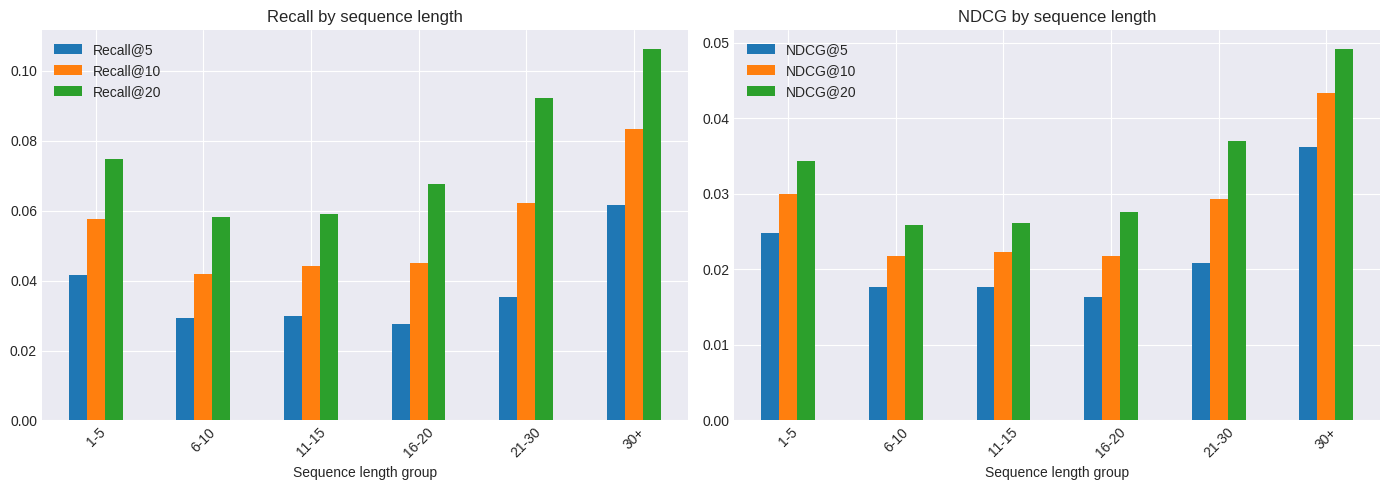

In [ ]:
fig, (ax_recall, ax_ndcg) = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in [(ax_recall, "Recall"), (ax_ndcg, "NDCG")]:
    recall_cols = [f"{metric}@{k}" for k in KS]
    group_df[recall_cols].plot(kind="bar", ax=ax)
    ax.set_title(f"{metric} by sequence length")
    ax.set_xlabel("Sequence length group")
    ax.set_xticklabels(group_df.index, rotation=45)
plt.show()

### Observations

**General trend** - SASRec's recommendation quality improves with sequence length. 

**Short sequences (1-5)** - It is the outlier. Maybe newer users don't have niche products and it is easier to recomend something for them